In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [10]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

data1 = pd.read_csv('True.csv')
print(data1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB
None


In [11]:
data = pd.read_csv('Fake.csv')
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
None


In [14]:
fake["label"] = 0   # Fake news
true["label"] = 1   # True news

In [15]:
fake.head()
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


# Data Cleaning

In [16]:
data = pd.concat([fake, true], axis=0)
data.reset_index(drop=True, inplace=True)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [18]:
data["content"] = data["title"] + " " + data["text"]

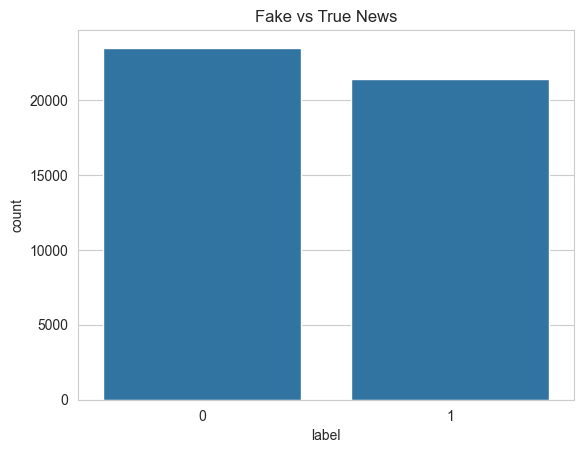

In [20]:
sns.countplot(data=data, x="label")
plt.title("Fake vs True News")
plt.show()

### Stopwords 
A stop word is a commonly used word (such as “the”, “a”, “an”, “in”) that a search engine has been programmed to ignore, both when indexing entries for searching and when retrieving them as the result of a search query.We would not want these words to take up space in our database, or taking up valuable processing time. For this, we can remove them easily, by storing a list of words that you consider to stop words. NLTK(Natural Language Toolkit) in python has a list of stopwords stored in 16 different languages. You can find them in the nltk_data directory. home/pratima/nltk_data/corpora/stopwords is the directory address.(Do not forget to change your home directory name)

### Lemmatisation
lemmatization looks beyond word reduction, and considers a language's full vocabulary to apply a morphological analysis to words. The lemma of 'was' is 'be' and the lemma of 'mice' is 'mouse'. Further, the lemma of 'meeting' might be 'meet' or 'meeting' depending on its use in a sentence.

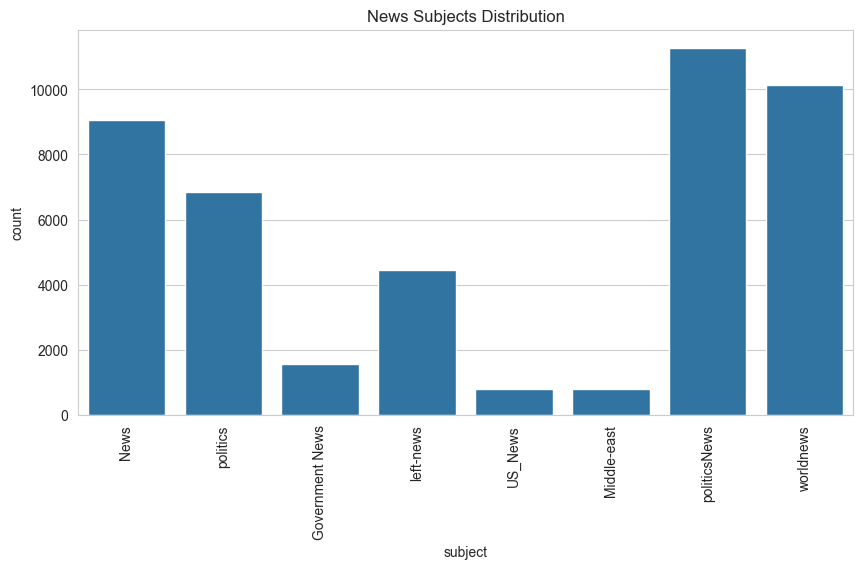

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(data=data, x="subject")
plt.xticks(rotation=90)
plt.title("News Subjects Distribution")
plt.show()

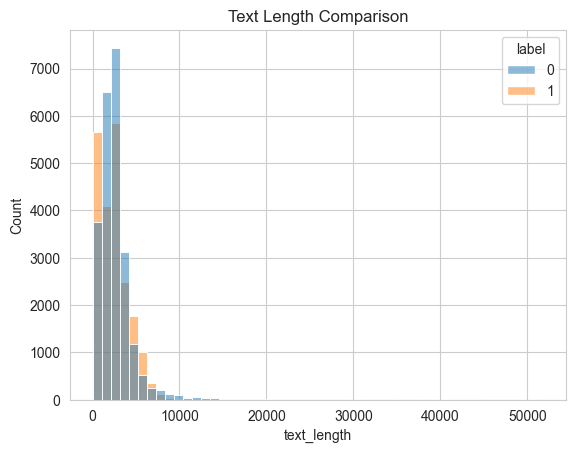

In [22]:
data["text_length"] = data["content"].apply(len)

sns.histplot(data=data, x="text_length", hue="label", bins=50)
plt.title("Text Length Comparison")
plt.show()

# Word Cloud

A word cloud is a collection, or cluster, of words depicted in different sizes. The bigger and bolder the word appears, the more often it’s mentioned within a given text and the more important it is.


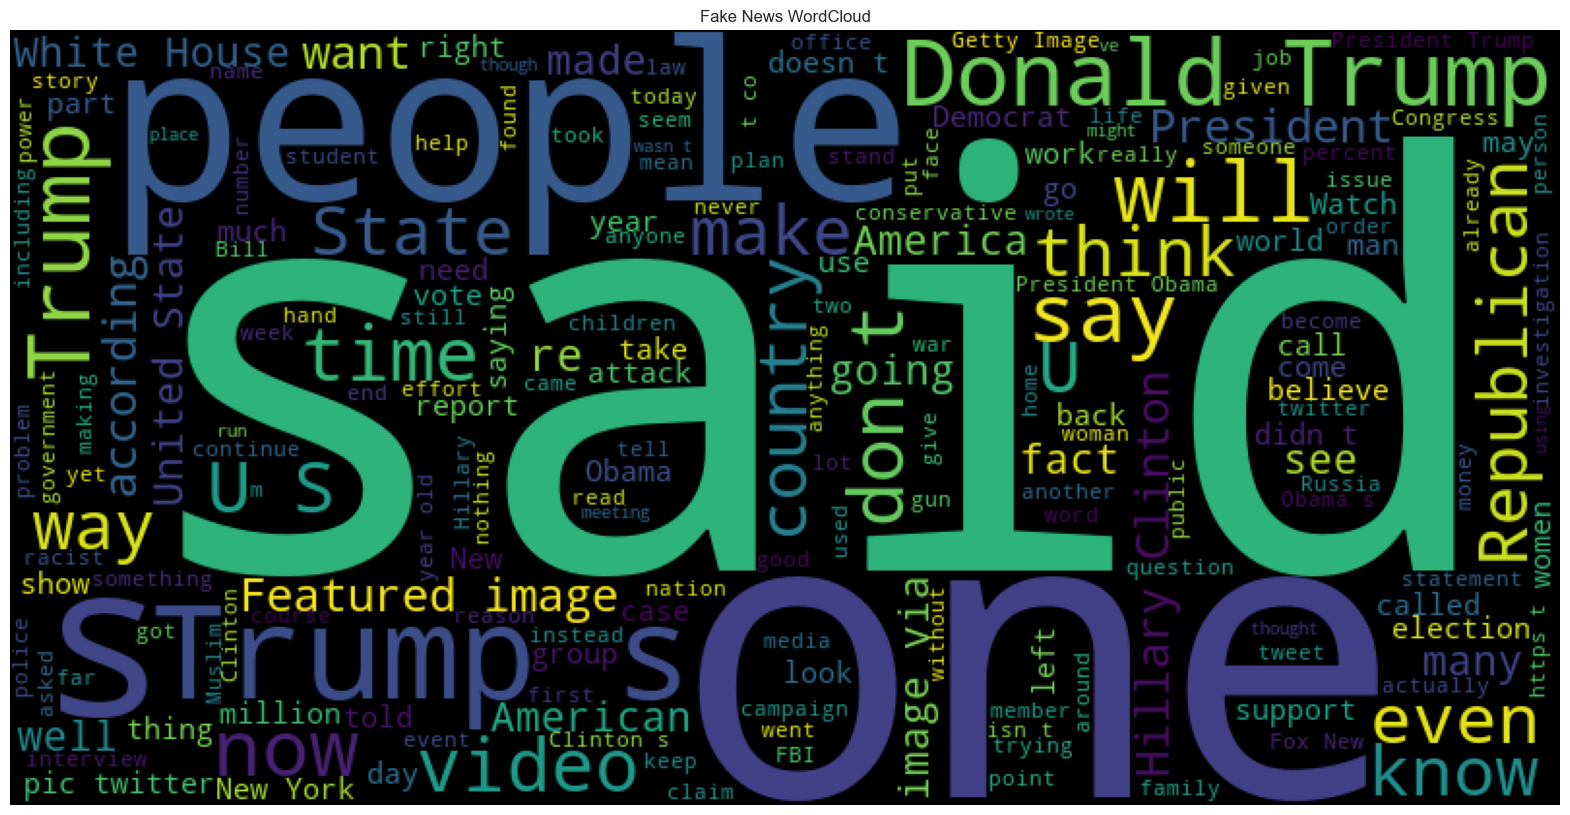

In [27]:
from wordcloud import WordCloud

fake_words = " ".join(data[data.label==0]["content"])

wc = WordCloud(width=800, height=400).generate(fake_words)
plt.figure(figsize = (20,20))
plt.imshow(wc)
plt.axis("off")
plt.title("Fake News WordCloud")
plt.show()

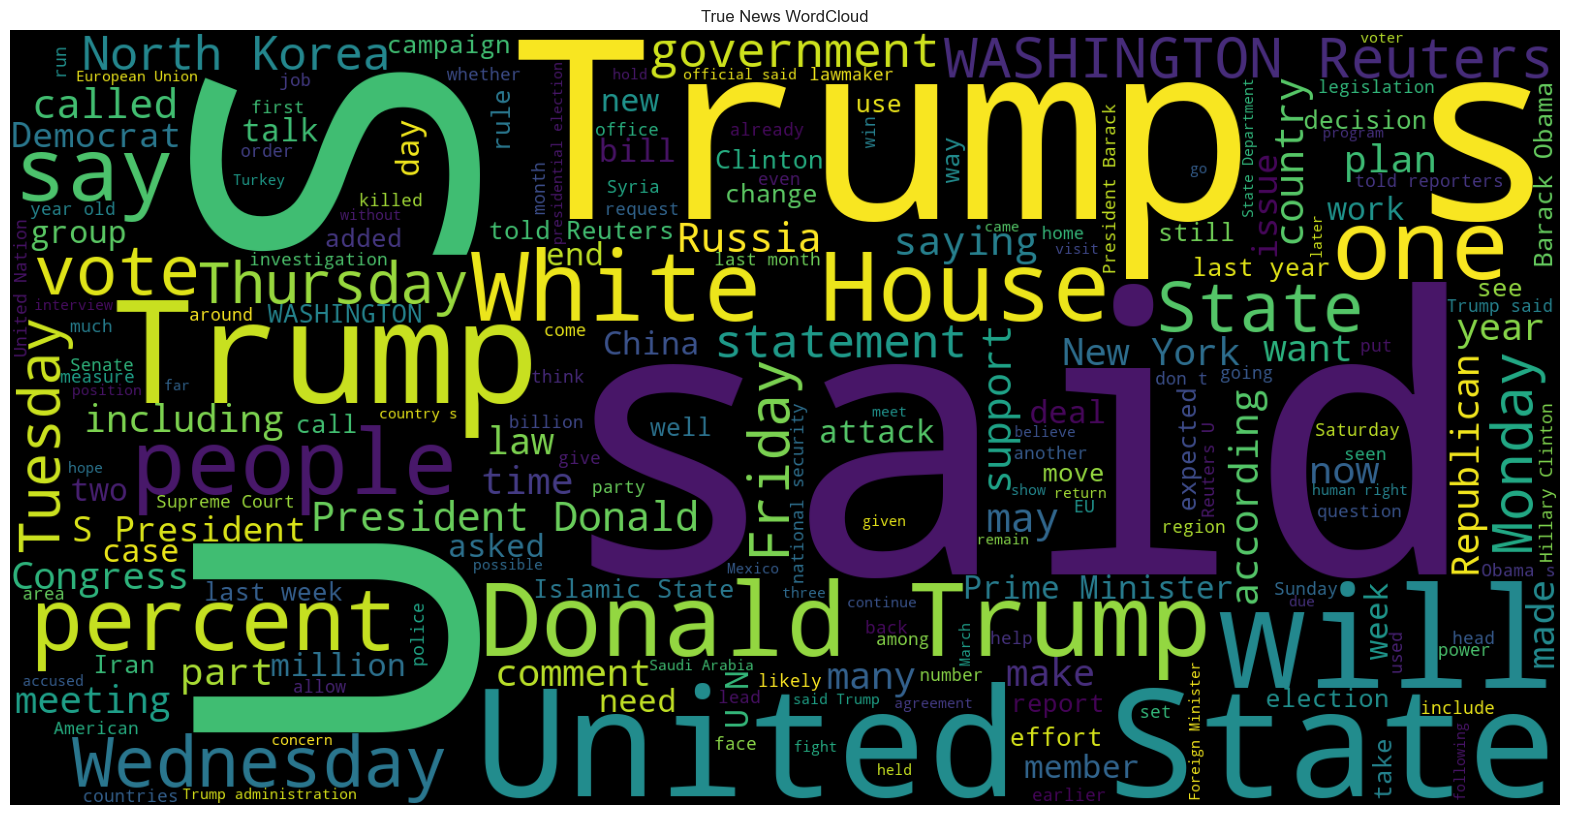

In [26]:
true_words = " ".join(data[data.label==1]["content"])

wc = WordCloud(width=1600, height=800).generate(true_words)
plt.figure(figsize = (20,20))
plt.imshow(wc)
plt.axis("off")
plt.title("True News WordCloud")
plt.show()

In [28]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hrgir\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [32]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

data["clean_content"] = data["content"].apply(clean_text)


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data["clean_content"])
y = data["label"]

#  Feature-Extraction & Model building 


In [35]:
#splitting the 
from sklearn.model_selection import train_test_split


X = data["clean_content"]   # feature
y = data["label"]           # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [36]:
#importing libraries to build a pipline
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC


In [37]:
#this pipe line will take the text and vectorise it , and then TF-IDF, then fitting the model

text_clf=Pipeline([("tfidf",TfidfVectorizer()),("clf",LinearSVC())])
text_clf.fit(X_train,y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [38]:
#making prediction using the model
predictions=text_clf.predict(X_test)

In [39]:
from sklearn import metrics
print(metrics.classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7778
           1       0.99      0.99      0.99      7039

    accuracy                           1.00     14817
   macro avg       1.00      1.00      1.00     14817
weighted avg       1.00      1.00      1.00     14817



In [40]:
#overall acuracy
print(metrics.accuracy_score(y_test,predictions))

0.9951407167442802


In [41]:
#confusion matrix
print(metrics.confusion_matrix(y_test,predictions))

[[7742   36]
 [  36 7003]]


In [52]:
test_news = "Middle East War EscalationUS troops were injured at a Saudi air base as attacks on Iran nuclear sites continue and the conflict enters its second month."

prediction = text_clf.predict([test_news])[0]

if prediction == 1:
    print("✅ True News")
else:
    print("❌ Fake News")

✅ True News
